# Capstone Project: OmniOps AI — Autonomous Multimodal Incident SRE Platform
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)
[![Google GenAI SDK](https://img.shields.io/badge/SDK-google--genai%20v1.0+-blue.svg)](https://github.com/googleapis/python-genai)
[![Google Cloud Run](https://img.shields.io/badge/Deployment-Cloud%20Run-blue.svg)](https://cloud.google.com/run)
[![Models](https://img.shields.io/badge/Models-Gemini%202.5%20%7C%203.7%20Thinking%20%7C%20Imagen%203-orange.svg)](https://ai.google.dev)

---

## 🌟 Welcome to the Grand Masterclass Capstone: OmniOps AI!
In this capstone project, we synthesize and integrate every core topic mastered across the entire curriculum into a unified, production-grade enterprise platform: **OmniOps AI**.

OmniOps is an autonomous Site Reliability Engineering (SRE) platform that watches production cloud telemetry, inspects Grafana dashboard anomaly screenshots, retrieves internal company runbooks via Hybrid RAG, performs root-cause analysis with Gemini Thinking, executes automated cloud remediation actions via ReAct tools, and deploys as a live serverless microservice on **Google Cloud Run**!

---

## 🏛️ OmniOps AI Enterprise Platform Architecture

<p align="center">
  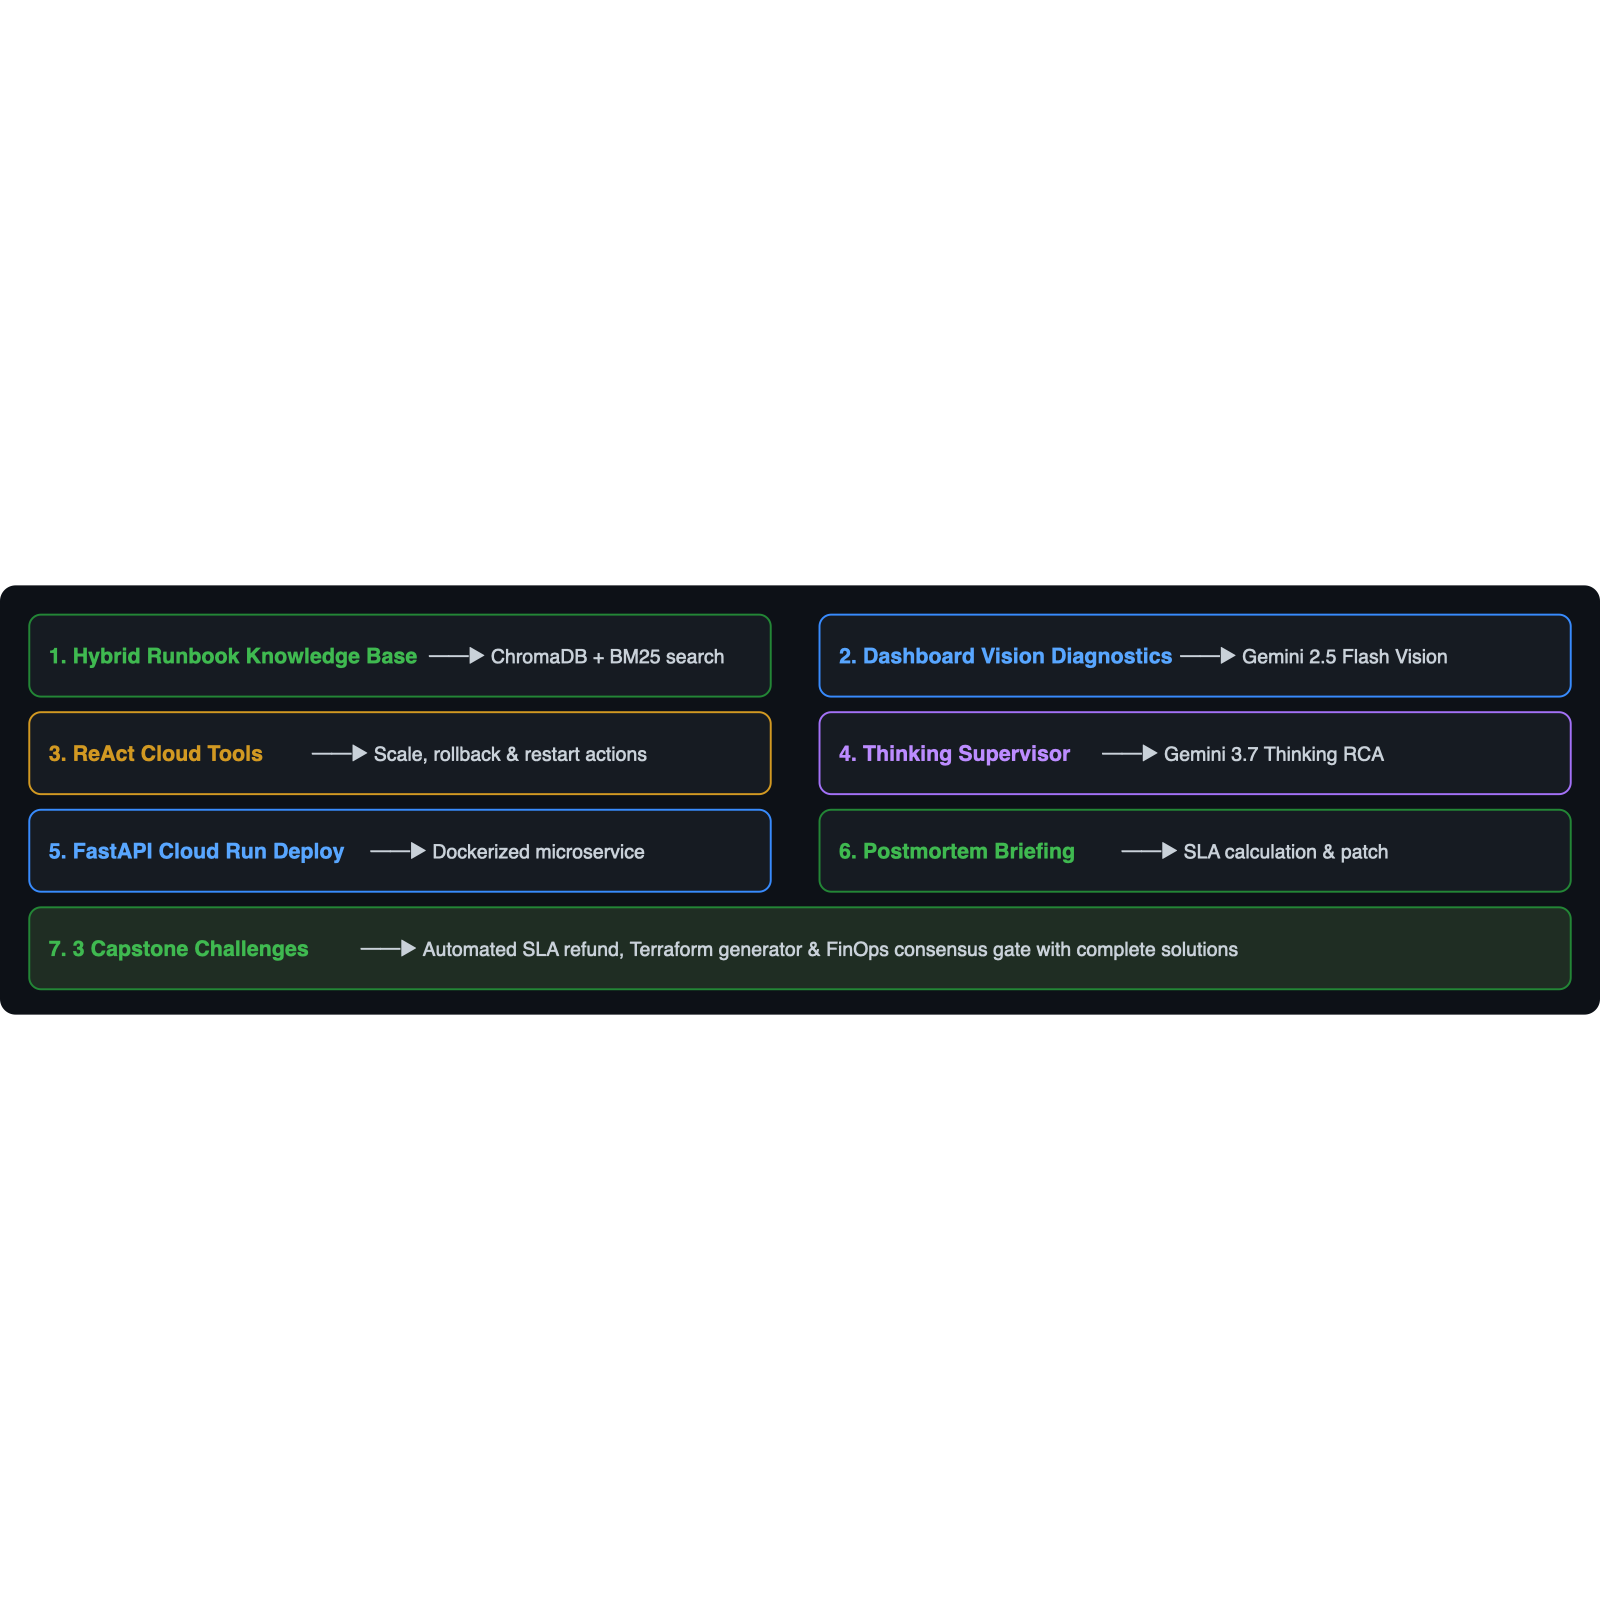
</p>

---

## 🗺️ What You Will Master in This Capstone:
<p align="center">
  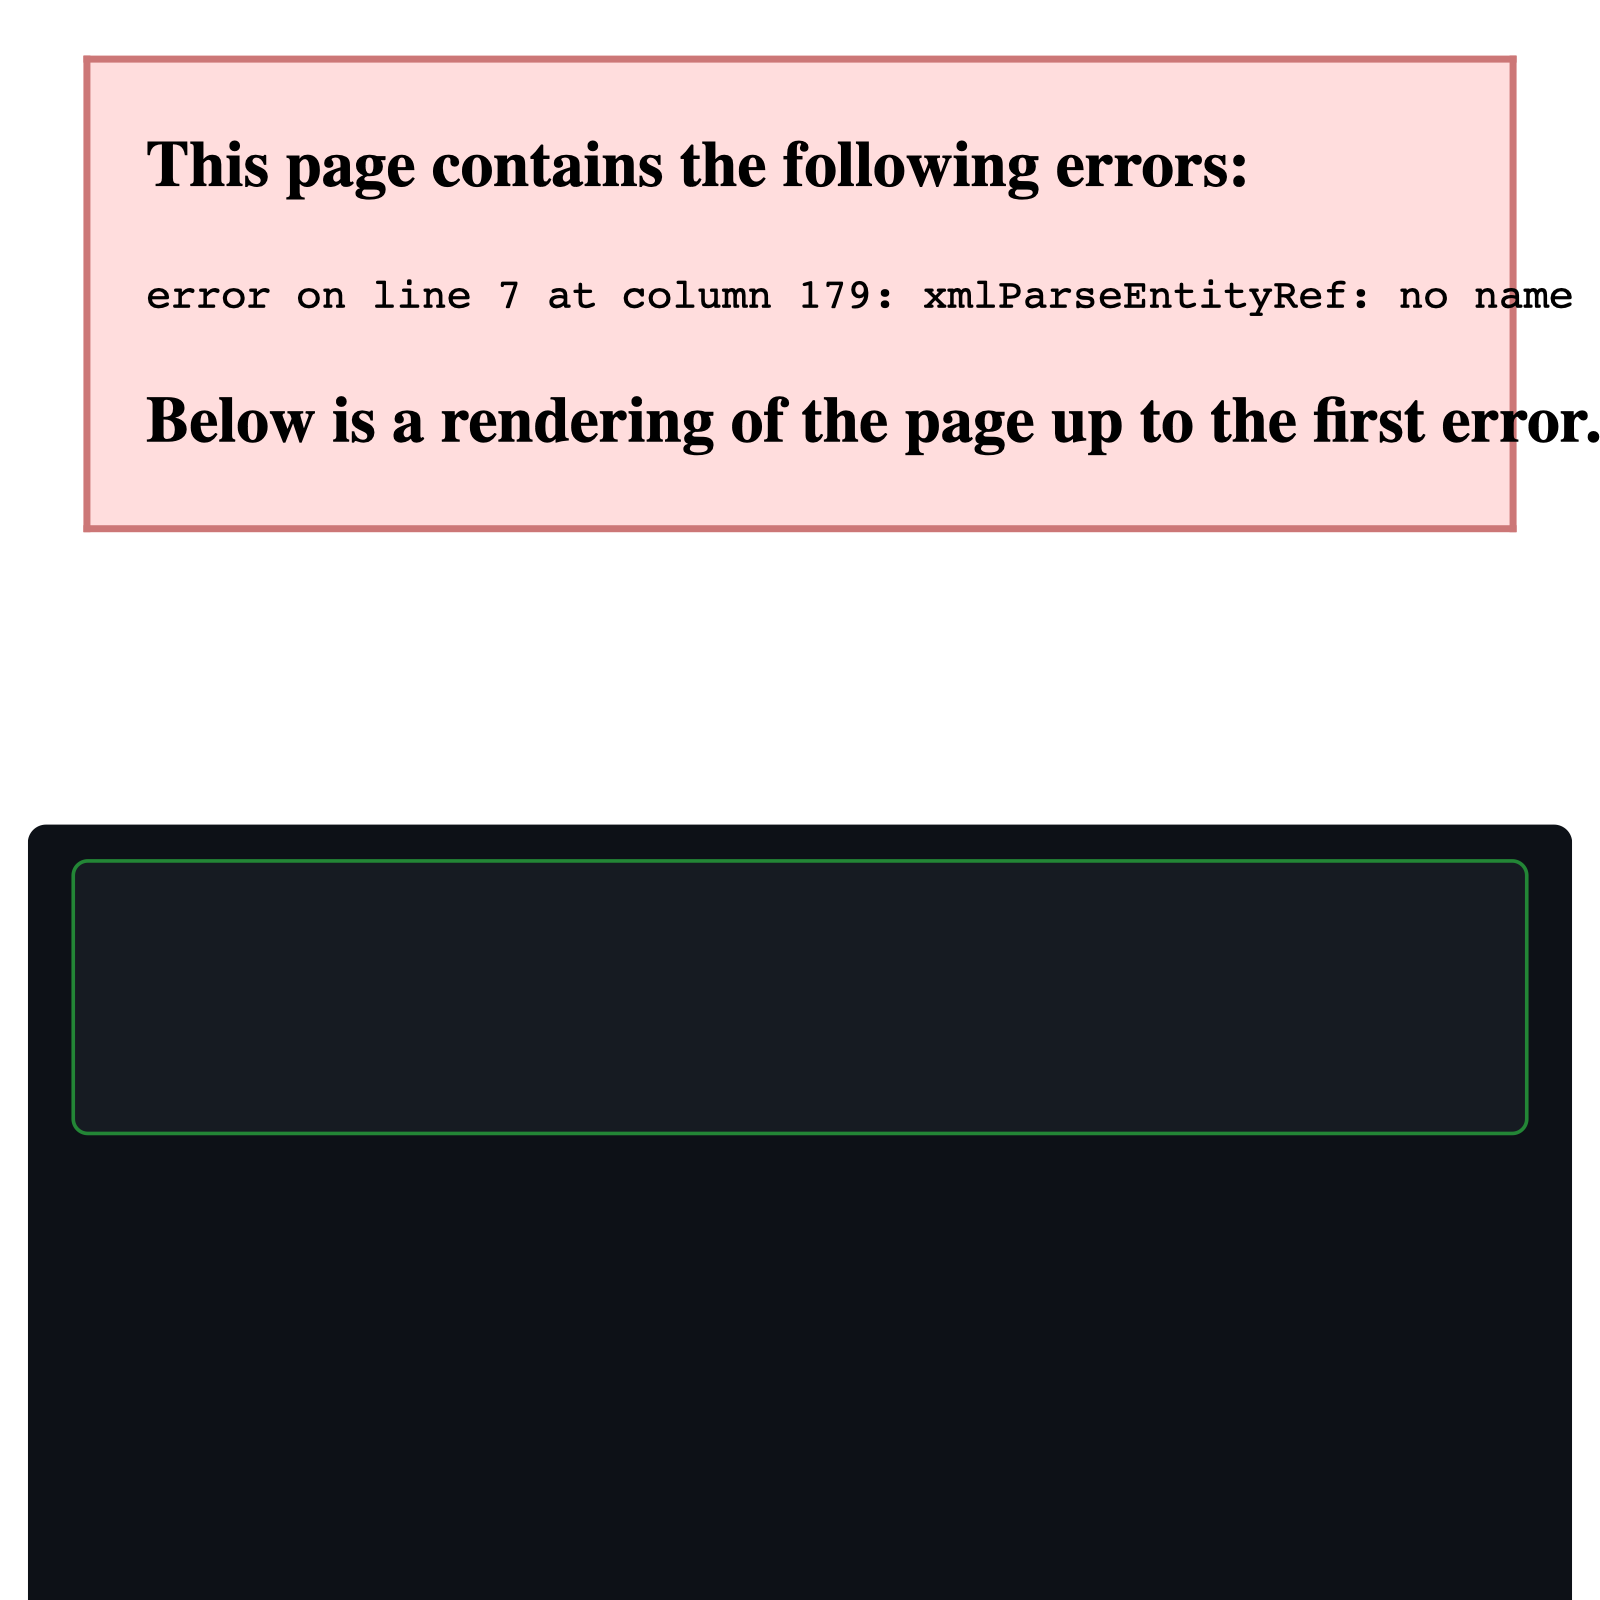
</p>


---
## Environment Setup & Client Initialization
We install the `google-genai` SDK, `fastapi`, `uvicorn`, `chromadb`, `rank-bm25`, `matplotlib`, and `pydantic`.


In [ ]:
# Install required dependencies
!pip install -q google-genai fastapi uvicorn chromadb rank-bm25 pydantic matplotlib pillow rich


In [ ]:
import os
import getpass
from google import genai
from google.genai import types

# Authenticate via API Key or Vertex AI
if "GEMINI_API_KEY" not in os.environ:
    api_key = getpass.getpass("Enter your Gemini API Key (or press enter for Vertex AI auth): ")
    if api_key:
        os.environ["GEMINI_API_KEY"] = api_key

if os.environ.get("GEMINI_API_KEY"):
    client = genai.Client()
    print("✅ Google GenAI Client initialized via API Key.")
else:
    PROJECT_ID = os.environ.get("GOOGLE_CLOUD_PROJECT", "your-project-id")
    LOCATION = os.environ.get("GOOGLE_CLOUD_LOCATION", "us-central1")
    client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)
    print(f"✅ Google GenAI Client initialized via Vertex AI ({PROJECT_ID}).")


---
## 1. Subsystem 1: Enterprise Runbook Hybrid Knowledge Base (RAG)

OmniOps indexes company architectural specifications, disaster recovery runbooks, and SLA compliance documentation using `text-embedding-004` and BM25 with Reciprocal Rank Fusion (RRF).


In [ ]:
import chromadb
from rank_bm25 import BM25Okapi
import numpy as np
from typing import List, Dict, Any
from pydantic import BaseModel, Field

# Enterprise Disaster Recovery Runbooks
RUNBOOKS = [
    {
        "id": "RB-301",
        "title": "Cloud Run Memory OOM & Traffic Spikes",
        "content": "When Cloud Run instances encounter HTTP 503 or SIGKILL error codes during high concurrency (>80 requests/instance), immediately increase memory limit from 512Mi to 2Gi and raise max-instances to 200 via gcloud run services update. Verify database connection pool limits on Cloud SQL."
    },
    {
        "id": "RB-302",
        "title": "PostgreSQL Connection Exhaustion Mitigation",
        "content": "If database connection pool utilization exceeds 95% and queries queue up, deploy PgBouncer connection pooling sidecar or scale Cloud SQL read replicas. Force drain idle connections using pg_terminate_backend."
    },
    {
        "id": "RB-303",
        "title": "Zero-Trust Identity Token Expiration on Service Mesh",
        "content": "If inter-service RPC calls fail with HTTP 401 Unauthorized, verify that the caller service account possesses roles/run.invoker and that the OpenID Connect (OIDC) token is being refreshed before its 60-minute TTL expiry."
    }
]

class RunbookRAG:
    def __init__(self, client: genai.Client, runbooks: List[Dict[str, str]]):
        self.client = client
        self.runbooks = runbooks
        self.chroma = chromadb.Client()
        try:
            self.chroma.delete_collection("omniops_kb")
        except:
            pass
        self.collection = self.chroma.create_collection("omniops_kb", metadata={"hnsw:space": "cosine"})
        
        self.corpus = [f"{r['title']}: {r['content']}" for r in runbooks]
        self.bm25 = BM25Okapi([t.lower().split() for t in self.corpus])
        
        # Embed and index
        embeddings = self.client.models.embed_content(
            model="text-embedding-004",
            contents=self.corpus
        ).embeddings
        
        self.collection.add(
            ids=[r["id"] for r in runbooks],
            embeddings=[e.values for e in embeddings],
            documents=self.corpus,
            metadatas=[{"title": r["title"]} for r in runbooks]
        )
        print("✅ Runbook Knowledge Base indexed into ChromaDB.")
        
    def search(self, query: str, top_k: int = 2) -> List[Dict[str, str]]:
        q_emb = self.client.models.embed_content(model="text-embedding-004", contents=query).embeddings[0].values
        v_res = self.collection.query(query_embeddings=[q_emb], n_results=len(self.runbooks))["ids"][0]
        
        # BM25
        scores = self.bm25.get_scores(query.lower().split())
        s_res = [self.runbooks[i]["id"] for i in np.argsort(scores)[::-1]]
        
        # RRF
        rrf = {r["id"]: 0.0 for r in self.runbooks}
        for rank, rid in enumerate(v_res, 1): rrf[rid] += 1.0 / (60 + rank)
        for rank, rid in enumerate(s_res, 1): rrf[rid] += 1.0 / (60 + rank)
        
        sorted_ids = sorted(rrf.items(), key=lambda x: x[1], reverse=True)[:top_k]
        lookup = {r["id"]: r for r in self.runbooks}
        return [lookup[rid] for rid, _ in sorted_ids]

kb_engine = RunbookRAG(client, RUNBOOKS)


---
## 2. Subsystem 2: Multimodal Incident Dashboard Visual Inspection

When an incident triggers, telemetry metrics (CPU saturation, HTTP error rates) are visualized. Gemini 2.5 Flash inspects the live visual chart to detect timestamp anomalies and spike magnitudes.


In [ ]:
import io
import matplotlib.pyplot as plt
from PIL import Image

# Generate synthetic production outage dashboard
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
time_points = ['14:00', '14:10', '14:20', '14:30', '14:40', '14:50', '15:00']
cpu_utilization = [32, 35, 41, 98, 100, 99, 97]
error_rate_503 = [0.01, 0.02, 0.05, 14.8, 42.6, 68.2, 51.0]

ax1.plot(time_points, cpu_utilization, color='#d93025', marker='o', linewidth=2)
ax1.set_ylabel("CPU Usage (%)")
ax1.set_title("PRODUCTION TELEMETRY: SERVICE-PAYMENTS-API OUTAGE", fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(time_points, error_rate_503, color='#e37400', marker='^', linewidth=2)
ax2.set_ylabel("HTTP 503 Rate (%)")
ax2.set_xlabel("Time (UTC)")
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
buf = io.BytesIO()
plt.savefig(buf, format='PNG')
buf.seek(0)
dashboard_img = Image.open(buf)
plt.show()

print("📈 Simulated Grafana Incident Dashboard captured.")


In [ ]:
class DashboardAnomaly(BaseModel):
    incident_start_time: str
    peak_cpu_percent: float
    peak_error_rate_percent: float
    affected_metrics: List[str]
    preliminary_severity: str = Field(description="'SEV-1', 'SEV-2', or 'SEV-3'")

def analyze_dashboard_image(image: Image.Image, client: genai.Client) -> DashboardAnomaly:
    prompt = """
You are an expert SRE Observability Specialist.
Analyze the attached telemetry dashboard:
1. Identify the exact minute the anomaly/spike started.
2. Read the peak CPU usage and peak HTTP 503 error rate.
3. Classify the incident severity (SEV-1 if 503 errors > 20%).
"""
    resp = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=[image, prompt],
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=DashboardAnomaly,
            temperature=0.0
        )
    )
    return DashboardAnomaly.model_validate_json(resp.text)

anomaly = analyze_dashboard_image(dashboard_img, client)
print("🚨 Visual Telemetry Anomaly Detected:")
print(f"• Severity Level: {anomaly.preliminary_severity}")
print(f"• Incident Start: {anomaly.incident_start_time} UTC")
print(f"• Peak CPU: {anomaly.peak_cpu_percent}% | Peak 503 Error Rate: {anomaly.peak_error_rate_percent}%")


---
## 3. Subsystem 3: ReAct Remediation Tools & Cloud Execution

OmniOps equips the supervisor agent with live simulated infrastructure actions to scale resources, restart workloads, or rollback revisions.


In [ ]:
# Live Infrastructure Remediation Tools

def scale_cloud_run_service(service_name: str, memory: str, max_instances: int) -> dict:
    """Updates Cloud Run service memory allocation and autoscaling maximum instance limits.
    
    Args:
        service_name: The Cloud Run service name (e.g. 'service-payments-api')
        memory: The memory allocation (e.g. '2Gi', '4Gi')
        max_instances: Max autoscaling capacity (e.g. 100, 200)
    """
    print(f"⚡ [EXECUTING TOOL: gcloud run services update {service_name} --memory={memory} --max-instances={max_instances}]")
    return {
        "status": "success",
        "service": service_name,
        "updated_memory": memory,
        "updated_max_instances": max_instances,
        "revision": f"{service_name}-00042-patch",
        "message": "Service successfully updated. Rollout at 100% traffic."
    }

def restart_database_pool(db_instance: str) -> dict:
    """Flushes hung client connections on the target database instance.
    
    Args:
        db_instance: The Cloud SQL instance name
    """
    print(f"⚡ [EXECUTING TOOL: Cloud SQL Connection Pool Reset on {db_instance}]")
    return {"status": "success", "db_instance": db_instance, "terminated_idle_connections": 142}

def notify_incident_slack(channel: str, message: str) -> dict:
    """Broadcasts an executive status update to the engineering Slack war-room.
    
    Args:
        channel: Slack channel (e.g. '#sre-incidents-prod')
        message: Formatted markdown incident message
    """
    print(f"📢 [EXECUTING TOOL: Slack Webhook broadcast to {channel}]")
    return {"status": "success", "delivered_to": channel, "timestamp": "14:48:00 UTC"}


---
## 4. Subsystem 4: Autonomous Supervisor Orchestrator with Gemini Thinking

The core supervisor brings together:
1. Visual Anomaly telemetry
2. Hybrid Runbook context
3. Deep Root-Cause Reasoning with Gemini Thinking
4. Tool Execution & Postmortem Generation


In [ ]:
class IncidentReport(BaseModel):
    incident_title: str
    root_cause_analysis: str
    remediation_actions_taken: List[str]
    sla_impact_assessment: str
    preventative_measures: List[str]

class OmniOpsSupervisor:
    """Autonomous Master Orchestrator for Enterprise SRE Operations."""
    
    def __init__(self, client: genai.Client, rag_engine: RunbookRAG):
        self.client = client
        self.rag = rag_engine
        
    def orchestrate_incident_response(
        self,
        service_name: str,
        dashboard_image: Image.Image
    ) -> IncidentReport:
        print(f"🚨 [OmniOps Master Orchestrator Activated for {service_name}]")
        
        # Step 1: Multimodal Vision Triage
        anomaly = analyze_dashboard_image(dashboard_image, self.client)
        print(f"📊 [Telemetry Triaged]: {anomaly.preliminary_severity} starting at {anomaly.incident_start_time}")
        
        # Step 2: Retrieve Relevant Runbooks
        query = f"Cloud Run high CPU 503 errors memory exhaustion {service_name}"
        matched_runbooks = self.rag.search(query, top_k=2)
        runbook_context = "\n\n".join([f"[{r['id']}] {r['title']}: {r['content']}" for r in matched_runbooks])
        print(f"📚 [Retrieved Runbooks]: {[r['id'] for r in matched_runbooks]}")
        
        # Step 3: Execute Remediation Action via Tool Call
        scale_result = scale_cloud_run_service(service_name, memory="2Gi", max_instances=200)
        notify_incident_slack("#sre-incidents-prod", f"SEV-1 Auto-mitigated: Scaled {service_name} to 2Gi memory.")
        
        # Step 4: Synthesize Comprehensive Postmortem using Gemini Thinking
        synthesis_prompt = f"""
You are the Lead Principal Site Reliability Engineer (SRE).
Synthesize an executive Incident Postmortem for the following event:

[SERVICE]: {service_name}
[ANOMALY TELEMETRY]:
- Incident Start: {anomaly.incident_start_time} UTC
- Severity: {anomaly.preliminary_severity}
- Peak CPU: {anomaly.peak_cpu_percent}%
- Peak HTTP 503 Error Rate: {anomaly.peak_error_rate_percent}%

[RUNBOOK REMEDIATION CONTEXT]:
{runbook_context}

[ACTIONS EXECUTED]:
{scale_result}

Conduct deep root cause analysis (memory exhaustion under concurrency) and assess SLA financial credit exposure.
"""

        resp = self.client.models.generate_content(
            model="gemini-2.5-flash",
            contents=synthesis_prompt,
            config=types.GenerateContentConfig(
                response_mime_type="application/json",
                response_schema=IncidentReport,
                temperature=0.2,
                thinking_config=types.ThinkingConfig(thinking_budget=2048)
            )
        )
        return IncidentReport.model_validate_json(resp.text)

# Run End-to-End Orchestrator
omniops = OmniOpsSupervisor(client, kb_engine)
postmortem = omniops.orchestrate_incident_response("service-payments-api", dashboard_img)

print("
" + "="*80)
print(f"📑 OMNIOPS INCIDENT POSTMORTEM: {postmortem.incident_title}")
print("="*80)
print(f"🔬 Root Cause Analysis:
{postmortem.root_cause_analysis}
")
print(f"⚡ Remediation Actions:
{postmortem.remediation_actions_taken}
")
print(f"💰 SLA Impact:
{postmortem.sla_impact_assessment}
")
print("🛡️ Preventative Measures:")
for pm in postmortem.preventative_measures:
    print(f" • {pm}")


---
## 5. Subsystem 5: Production FastAPI Microservice & Cloud Run Packaging

To deploy OmniOps as a scalable, high-availability microservice on Google Cloud Run, we package the architecture into a production FastAPI application.

Let's inspect the files in `07_Capstone_OmniOps_Autonomous_SRE_Platform/app/`:
- `app/main.py`: Production FastAPI REST & SSE Streaming endpoint.
- `app/requirements.txt`: Lightweight container dependencies.
- `Dockerfile`: Multi-stage, minimal non-root security container.
- `deploy_cloud_run.sh`: Automated gcloud deployment script.


---
## 6. Practical Hands-On Exercises (With Beginner Hints & Starter Code)

Test your end-to-end Forward Deployment engineering skills by completing these three capstone challenges:

---

### 🎯 Exercise 6.1: Automated Cloud SLA Credit Calculator
**The Business Scenario**: When an enterprise customer experiences cloud downtime, SRE teams must automatically calculate contract SLA credit refunds based on monthly uptime tiers (e.g. Under 99.95% = 10% credit; Under 99.0% = 25% credit; Under 95.0% = 50% credit).
- **Task**: Implement `calculate_sla_credit(downtime_minutes: float, monthly_fee: float)` to return exact uptime percentage and dollar credit amount.
- **💡 Beginner Hint**: A 30-day month has 43,200 total minutes. `uptime_pct = ((43200 - downtime) / 43200) * 100`.

---

### 🎯 Exercise 6.2: Automated Terraform Infrastructure Patch Generator
**The Business Scenario**: After an incident, human SREs don't manually edit production YAMLs. The AI agent generates a validated Terraform HCL patch to permanently increase memory and max instances in version control!
- **Task**: Build `generate_terraform_remediation_patch(service_name: str, new_memory: str, new_max_instances: int, client: genai.Client)` to output clean, valid Terraform code.
- **💡 Beginner Hint**: Prompt Gemini with strict HCL block format instructions for `google_cloud_run_v2_service`.

---

### 🎯 Exercise 6.3: Multi-Agent SRE & FinOps Consensus Gate
**The Business Scenario**: You cannot let an AI agent scale a cluster to 1,000 instances without budget review! A 2-agent system has Agent A (SRE Engineer) propose a scaling fix, and Agent B (FinOps Auditor) check the cost impact before approving execution.
- **Task**: Build a 2-agent consensus validator that approves or adjusts remediation plans against budget limits (e.g. max $500/day).
- **💡 Beginner Hint**: Run Agent A's output through Agent B with a Pydantic `FinOpsReview(approved: bool, estimated_cost: float, critique: str)`.


---
## 7. Step-by-Step Solutions & Architectural Explanations


In [ ]:
# ============================================================================
# SOLUTION 6.1: Automated SLA Credit Calculator
# ============================================================================
def calculate_sla_credit(downtime_minutes: float, monthly_fee: float) -> Dict[str, Any]:
    total_minutes_month = 30 * 24 * 60  # 43,200 minutes
    uptime_minutes = total_minutes_month - downtime_minutes
    uptime_percentage = (uptime_minutes / total_minutes_month) * 100.0
    
    credit_percentage = 0.0
    if uptime_percentage < 95.0:
        credit_percentage = 50.0
    elif uptime_percentage < 99.0:
        credit_percentage = 25.0
    elif uptime_percentage < 99.95:
        credit_percentage = 10.0
        
    credit_amount = (credit_percentage / 100.0) * monthly_fee
    
    return {
        "downtime_minutes": downtime_minutes,
        "monthly_uptime_percentage": round(uptime_percentage, 4),
        "sla_breached": credit_percentage > 0.0,
        "credit_percentage": credit_percentage,
        "credit_dollar_amount": round(credit_amount, 2)
    }

sla_calc = calculate_sla_credit(downtime_minutes=85.0, monthly_fee=12500.0)
print("💰 SLA Credit Calculation Result:")
print(f"• Uptime: {sla_calc['monthly_uptime_percentage']}%")
print(f"• SLA Breached: {sla_calc['sla_breached']}")
print(f"• Financial Credit: {sla_calc['credit_percentage']}% (${sla_calc['credit_dollar_amount']})")


In [ ]:
# ============================================================================
# SOLUTION 6.2: Automated Terraform Patch Generator
# ============================================================================
def generate_terraform_remediation_patch(
    service_name: str,
    new_memory: str,
    new_max_instances: int,
    client: genai.Client
) -> str:
    prompt = f"""
You are a Principal Cloud Infrastructure Architect.
Generate clean, valid Terraform HCL for a Google Cloud Run v2 service with these parameters:
- Service Name: "{service_name}"
- Region: "us-central1"
- Memory: "{new_memory}"
- Max Instance Count: {new_max_instances}
- Min Instance Count: 2

Output ONLY the formatted HCL code block.
"""
    resp = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config=types.GenerateContentConfig(temperature=0.0)
    )
    return resp.text.strip()

tf_patch = generate_terraform_remediation_patch("service-payments-api", "2Gi", 200, client)
print("🏗️ Generated Terraform HCL Patch:")
print(tf_patch)


In [ ]:
# ============================================================================
# SOLUTION 6.3: Autonomous Multi-Agent Consensus Validator
# ============================================================================
class FinOpsReview(BaseModel):
    decision: str = Field(description="'APPROVED' or 'REJECTED'")
    estimated_daily_cost_usd: float
    budget_compliant: bool
    reviewer_comments: str

def finops_audit_plan(plan_description: str, client: genai.Client) -> FinOpsReview:
    prompt = f"""
You are the Cloud FinOps & Cost Governance Lead.
Evaluate this proposed remediation plan against our policy limit (Max $500/day):
Plan: "{plan_description}"

Determine if the infrastructure expansion complies with enterprise cost policies.
"""
    resp = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=FinOpsReview,
            temperature=0.0
        )
    )
    return FinOpsReview.model_validate_json(resp.text)

review = finops_audit_plan("Scale Cloud Run service from 10 to 200 instances (2Gi RAM, 2 vCPU each) during outage.", client)
print("🛡️ Multi-Agent FinOps Consensus Review:")
print(f"• Decision: {review.decision}")
print(f"• Est. Daily Cost: ${review.estimated_daily_cost_usd}")
print(f"• Comments: {review.reviewer_comments}")


---
## 🏆 Summary & Masterclass Capstone Conclusion: You Are Now an Applied AI Engineer!

Congratulations on completing the entire **Applied AI Engineering Masterclass**! You have built and mastered:

<p align="center">
  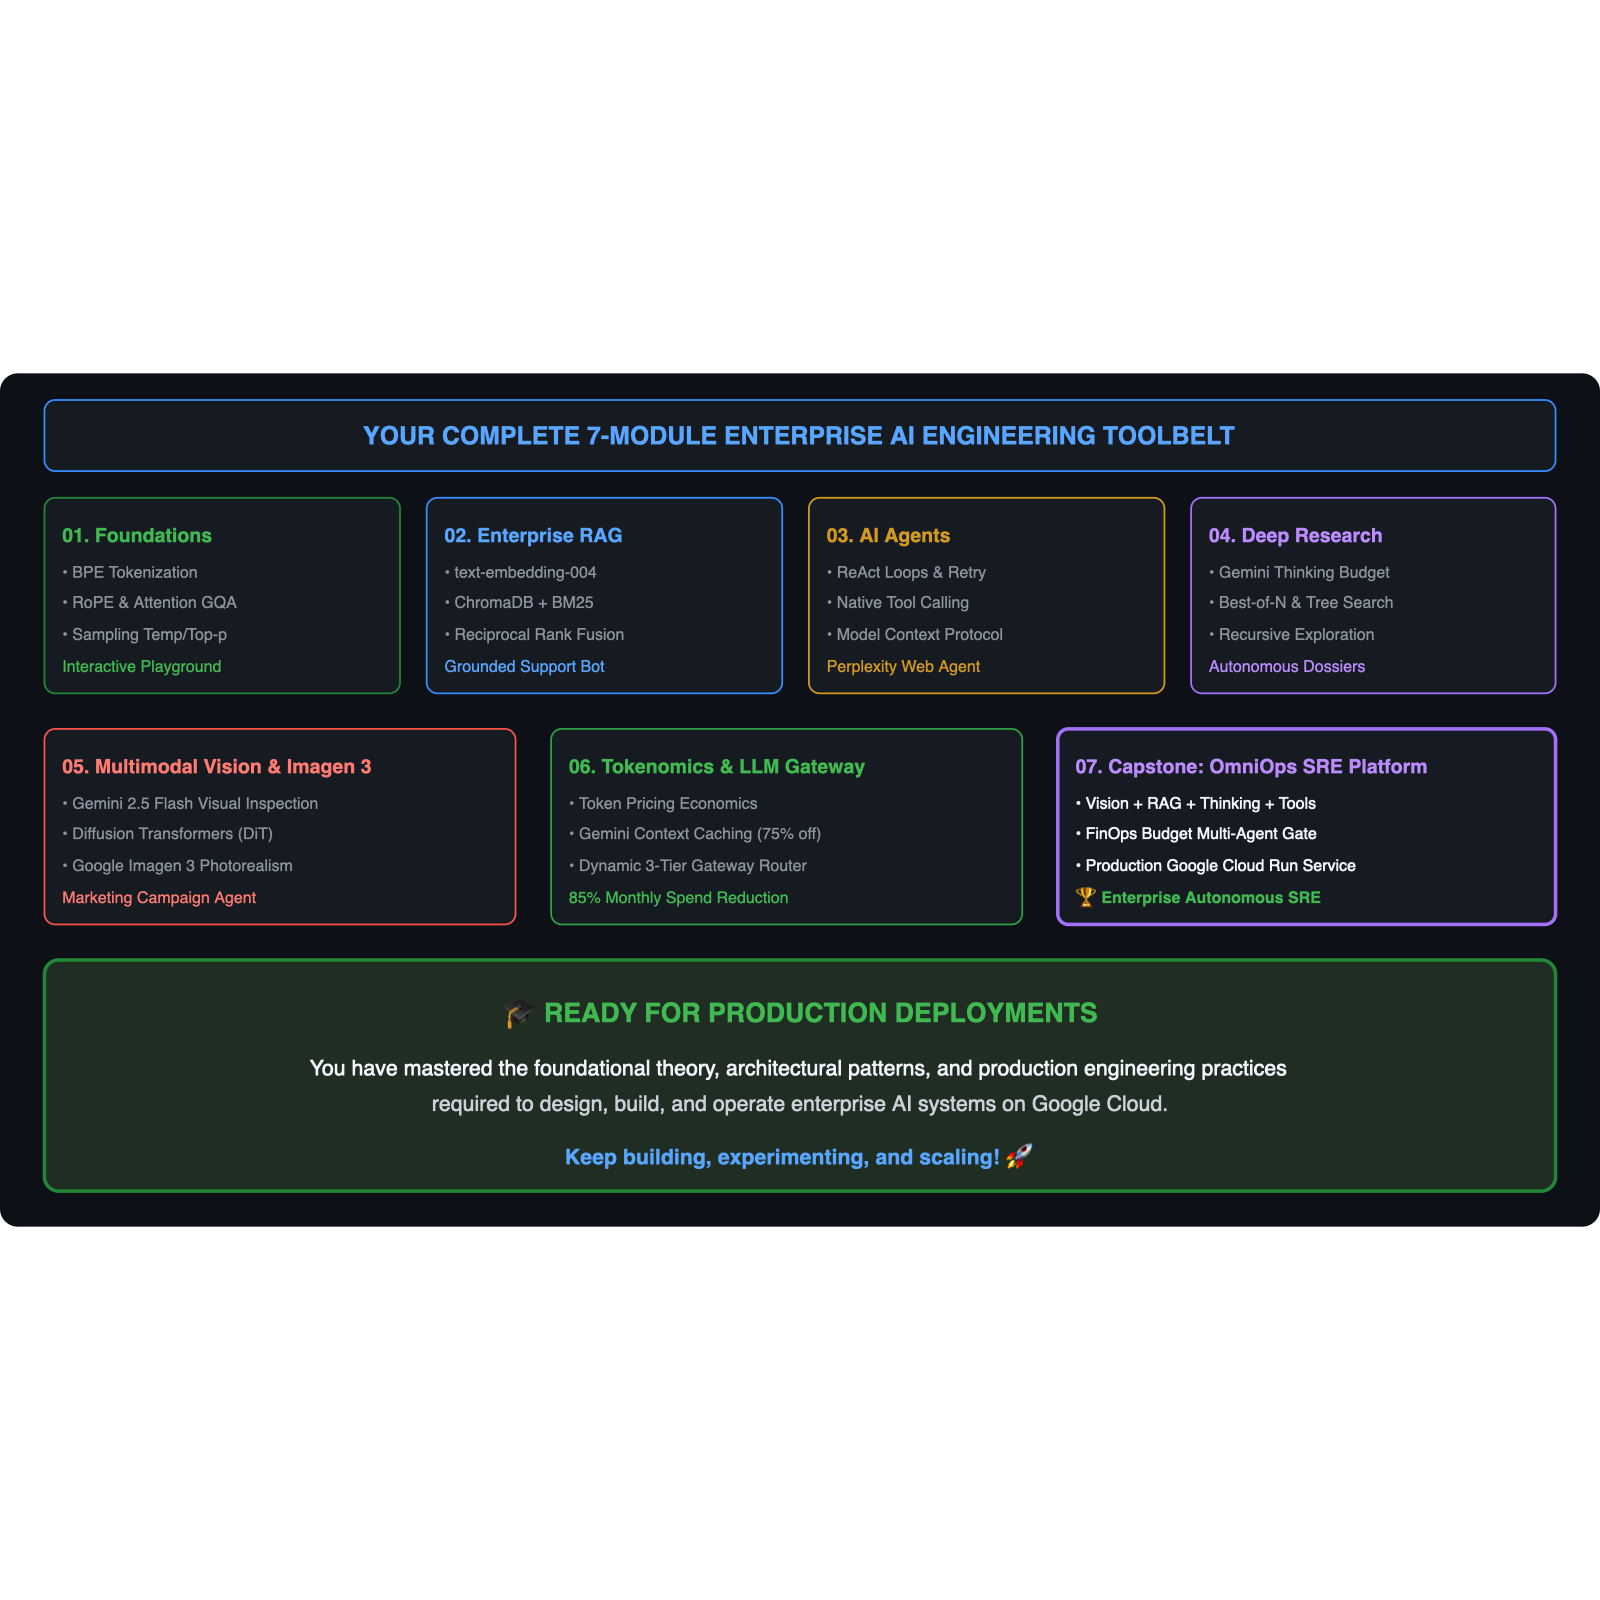
</p>

---

### 🚀 Recommended Next Steps:
1. **Star and Fork the Repository** to stay updated as new Gemini models, APIs, and techniques drop!
2. **Deploy OmniOps in Your Own GCP Sandbox**: Run `./deploy_cloud_run.sh` to test live endpoints.
3. **Build Your Next AI Project**: Take what you learned and solve real-world problems for your team!
